In [1]:
import pandas as pd
import numpy as np
import matplotlib
import ast
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

#폰트 설정(없으면 영문으로 나옴)
try:
    font_path = [f for f in fm.findSystemFonts() if 'NanumGothic' in f or 'Malgun' in f or 'AppleGothic' in f]
    if font_path:
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path[0]).get_name()
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False

In [2]:
full = pd.read_csv('../Soyun_EDA/final_eda.csv')

In [3]:
received = (
    full.loc[full['event'] == 'offer received', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_received'})
    .sort_values(['customer_id', 'offer_id', 't_received'])
    .reset_index(drop=True)
)
viewed = (
    full.loc[full['event'] == 'offer viewed', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_viewed'})
    .sort_values(['customer_id', 'offer_id', 't_viewed'])
    .reset_index(drop=True)
)
completed = (
    full.loc[full['event'] == 'offer completed', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_completed'})
    .sort_values(['customer_id', 'offer_id', 't_completed'])
    .reset_index(drop=True)
)

# 같은 고객, 같은 오퍼를 수신 받았을 때 instance_id 각각 부여 (모두 1로, 똑같은 객체가 들어오면 그때 2)
received['instance_id'] = received.groupby(['customer_id', 'offer_id']).cumcount() + 1

portfolio_dur = (
    full[['offer_id', 'duration']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)
received = received.merge(portfolio_dur, on='offer_id', how='left')

# [경계조건] t_expire = t_received + duration * 24
# - transcript.time 단위: 시간(hour), portfolio.duration 단위: 일(day) → *24 변환
# - 경계: t_received <= event_time <= t_expire (양 끝 포함, closed interval)
#   → 수신 시각과 만료 시각 정확히 일치하는 이벤트도 유효로 처리
#   → strict (<) 버전은 사용하지 않음 (수신 즉시 이벤트 발생 사례 존재)
received['t_expire'] = received['t_received'] + received['duration'] * 24

recv_keys = received[['customer_id', 'offer_id', 't_received', 'instance_id', 't_expire']]

In [4]:
def interval_join(events_df, event_time_col):
    # [경계조건] t_received <= t_event <= t_expire (양 끝 포함)
    # [ambiguous match 처리 규칙]
    #   - 같은 이벤트가 복수의 수신 구간에 걸칠 경우(ambiguous_match=1),
    #     t_received가 가장 최근인(=직전에 수신된) instance를 선택
    #   - 근거: 가장 최근 수신 오퍼에 반응했을 가능성이 가장 높다고 가정
    events_df = events_df.copy()
    events_df['_row_id'] = range(len(events_df))
    merged = events_df.merge(recv_keys, on=['customer_id', 'offer_id'], how='left') # 겹치는게 엄청 많을 거임 on 조건이 인스턴스 조건 뿐이므로!
    valid = merged[ # 하지만 여기서 필터링을 걸어줘서 구간 내에 포함되는 view와 receive 행만 추출
        (merged['t_received'] <= merged[event_time_col]) &
        (merged[event_time_col] <= merged['t_expire'])
    ].copy()
    match_cnt = ( # 같은 view 행에서 몇개의 receive 행이 연결되었는지 카운트
        valid.groupby('_row_id')['instance_id']
        .count().reset_index(name='match_count')
    )
    valid = valid.merge(match_cnt, on='_row_id')
    valid['ambiguous_match'] = (valid['match_count'] > 1).astype(int)
    valid = (
        valid.sort_values('t_received', ascending=False) # 같은 구간내에 여러개의 수신 인스턴스가 존재한다면 최근 수신된 인스턴스 선택
        .drop_duplicates(subset='_row_id', keep='first')
        .drop(columns='_row_id')
    )
    return valid

view_map = interval_join(viewed, 't_viewed')
comp_map = interval_join(completed, 't_completed')


In [5]:
view_map = view_map.sort_values(by=['customer_id','offer_id'])
view_map

,customer_id,offer_id,t_viewed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,372,informational,336,1,432.0,1,0
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,192,informational,168,1,240.0,1,0
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,456,bogo,408,1,528.0,1,0
3,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,540,discount,504,1,744.0,1,0
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,630,bogo,576,2,696.0,1,0
...,...,...,...,...,...,...,...,...,...
58929,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,582,discount,576,3,744.0,1,0
58928,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
58926,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,354,discount,336,1,504.0,1,0
58930,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,534,bogo,504,1,672.0,1,0


In [6]:
comp_map = comp_map.sort_values(by=['customer_id','offer_id'])
comp_map

,customer_id,offer_id,t_completed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,576,1,744.0,1,0
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414,bogo,408,1,528.0,1,0
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528,discount,504,1,744.0,1,0
3,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,576,discount,408,1,648.0,1,0
4,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,252,discount,168,1,336.0,1,0
...,...,...,...,...,...,...,...,...,...
35373,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,576,3,744.0,2,1
35371,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
35369,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,384,discount,336,1,504.0,1,0
35374,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,504,1,672.0,1,0


In [7]:
# == [품질 체크 1] 이벤트 중복 매핑 확인 ==
dup_view_map = view_map[view_map.duplicated()]
print(f"중복건: {len(dup_view_map)}개") # 중복 없음

dup_comp_map = comp_map[comp_map.duplicated()]
print(f"중복건: {len(dup_comp_map)}개") # 중복 존재

중복건: 0개
중복건: 397개


In [8]:
n_no_match_v = len(viewed) - len(view_map)
n_no_match_c = len(completed) - len(comp_map)
n_ambig_v = view_map['ambiguous_match'].sum()
n_ambig_c = comp_map['ambiguous_match'].sum()
print(f"열람: 유효 구간 밖 {n_no_match_v:,}건 / ambiguous {n_ambig_v:,}건") # 한 view 행이 여러 receive 행과 연결될 수 있는 모호한 건 수
print(f"완료: 유효 구간 밖 {n_no_match_c:,}건 / ambiguous {n_ambig_c:,}건") # 한 complete 행이 여러 receive 행과 연결될 수 있는 모호한 건 수

view_summary = (
    view_map.groupby(['customer_id', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_viewed=('t_viewed', 'min'),
        last_viewed=('t_viewed', 'max'),
        view_count=('t_viewed', 'count'),
        view_ambiguous=('ambiguous_match', 'max')
    )
)

comp_summary = (
    comp_map.groupby(['customer_id', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_completed=('t_completed', 'min'),
        last_completed=('t_completed', 'max'),
        complete_count=('t_completed', 'count'),
        comp_ambiguous=('ambiguous_match', 'max')
    )
)

열람: 유효 구간 밖 1,158건 / ambiguous 2,339건
완료: 유효 구간 밖 0건 / ambiguous 1,776건


In [9]:
view_summary[view_summary['view_count']>1]

,customer_id,offer_id,instance_id,first_viewed,last_viewed,view_count,view_ambiguous


In [10]:
comp_summary[(comp_summary['complete_count']>1)&(comp_summary['first_completed']!=comp_summary['last_completed'])]

,customer_id,offer_id,instance_id,first_completed,last_completed,complete_count,comp_ambiguous
294,0246e7cc7a3d4a98a940cb13776b5b55,fafdcd668e3743c1bb461111dcafc2a4,2,582,624,2,1
505,041fd7c6b796430a867c4e03d2ff8f4d,0b1e1539f2cc45b7b9fa7c272da2e1d7,3,648,702,2,1
745,05e6bcb70fe14e0da4730527ca35a4ae,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,510,540,2,1
754,05f4d69f73024172a23a350e611166b4,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,414,432,2,1
904,072290a7410e49d3a1e45a89c92c58f3,2298d6c36e964ae4a3e7e9706d1fb8c2,2,432,468,2,1
...,...,...,...,...,...,...,...
30753,edc7b04392144da9979f3077095f268a,fafdcd668e3743c1bb461111dcafc2a4,3,474,498,2,1
31489,f3934f05d51f47c7a470661cbb774075,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,456,462,2,1
31996,f74033a8c6834303bd1b3ef0c98d11d8,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,576,714,2,1
31999,f7465d18ba7f4e43b99ccabf141d421d,2906b810c7d4411798c6938adc9daaa5,3,504,594,2,1


In [11]:
# == [품질 체크 2] 이벤트 중복 매핑 & tie-break 확인 ==

# 1. 한 이벤트가 여러 instance에 중복 매핑되지 않는지
dup_view = view_summary.duplicated().sum()
dup_comp = comp_summary.duplicated().sum()
print(f"[중복 매핑] view_summary: {dup_view}건 / comp_summary: {dup_comp}건 (0이어야 정상)")
assert dup_view == 0, f'view_map 중복 매핑 {dup_view}건 존재'
assert dup_comp == 0, f'comp_summary 중복 매핑 {dup_comp}건 존재'

# 2. ambiguous match 건수 확인 (tie-break: 최근 t_received 기준 1개 선택)
ambig_v = view_summary['view_ambiguous'].sum()
ambig_c = comp_summary['comp_ambiguous'].sum()
print(f"[Ambiguous match] view: {ambig_v:,}건 / comp: {ambig_c:,}건 → 최근 수신 instance 선택")

print("\n✓ 중복 매핑 체크 통과")

"""
[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)
[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택

✓ 중복 매핑 체크 통과
"""

[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)
[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택

✓ 중복 매핑 체크 통과


'\n[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)\n[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택\n\n✓ 중복 매핑 체크 통과\n'

In [ ]:
funnel_instance = (
    received.merge(view_summary, on=['customer_id', 'offer_id', 'instance_id'], how='left')
            .merge(comp_summary, on=['customer_id', 'offer_id', 'instance_id'], how='left')
)

funnel_instance['gap_to_first_view'] = funnel_instance['first_viewed'] - funnel_instance['t_received']
funnel_instance['gap_to_first_complete'] = funnel_instance['first_completed'] - funnel_instance['t_received']
funnel_instance['is_viewed'] = funnel_instance['first_viewed'].notna()
funnel_instance['is_completed'] = funnel_instance['first_completed'].notna()
funnel_instance['completed_without_prior_view'] = (
    (funnel_instance['is_completed'] & ~funnel_instance['is_viewed'])
    | (funnel_instance['first_completed'] < funnel_instance['first_viewed'])  # 완료가 열람보다 먼저인 경우
)
funnel_instance['completed_with_prior_view'] = (
    funnel_instance['is_completed'] & funnel_instance['is_viewed']
    & (funnel_instance['first_viewed'] <= funnel_instance['first_completed'])
)

# prior view가 있고 시간 순서가 맞는 경우에만 gap 계산 (시간 순서 확실한 것만)
mask = (
    funnel_instance['first_viewed'].notna() &
    funnel_instance['first_completed'].notna() &
    (funnel_instance['first_viewed'] < funnel_instance['first_completed'])
)
funnel_instance['gap_first_view_to_first_complete'] = np.where(
    mask,
    funnel_instance['first_completed'] - funnel_instance['first_viewed'],
    np.nan
)

In [225]:
first_viewed_instance = ( # 같은 오퍼를 여러번 받은 경우 이벤트를 '열람'한 오퍼
    funnel_instance[funnel_instance['is_viewed']]
    .groupby(['customer_id','offer_id'])['instance_id']
    .min()
    .reset_index(name = 'first_viewed_instance')
)

first_viewed_instance['first_viewed_instance'].value_counts() # 경향만 보는 것으로!

first_viewed_instance
1    47024
2     1146
3       42
4        1
Name: count, dtype: int64

In [14]:
funnel_instance.sort_values(by=['customer_id','offer_id','instance_id'])

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,completed_within_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,False,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,False,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,False,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,False,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76272,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,336,discount,1,7.0,504.0,354.0,354.0,1.0,0.0,384.0,384.0,1.0,0.0,18.0,48.0,True,True,False,True,30.0
76273,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,408,discount,2,7.0,576.0,414.0,414.0,1.0,1.0,414.0,414.0,1.0,1.0,6.0,6.0,True,True,False,True,NaN
76274,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,3,7.0,744.0,582.0,582.0,1.0,0.0,576.0,576.0,1.0,1.0,6.0,0.0,True,True,True,False,NaN
76275,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,1,7.0,672.0,534.0,534.0,1.0,0.0,504.0,504.0,1.0,0.0,30.0,0.0,True,True,True,False,NaN


In [15]:
funnel_instance.info()

<class 'pandas.DataFrame'>
RangeIndex: 76277 entries, 0 to 76276
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   customer_id                       76277 non-null  str    
 1   offer_id                          76277 non-null  str    
 2   t_received                        76277 non-null  int64  
 3   offer_type                        76277 non-null  str    
 4   instance_id                       76277 non-null  int64  
 5   duration                          76277 non-null  float64
 6   t_expire                          76277 non-null  float64
 7   first_viewed                      56567 non-null  float64
 8   last_viewed                       56567 non-null  float64
 9   view_count                        56567 non-null  float64
 10  view_ambiguous                    56567 non-null  float64
 11  first_completed                   33101 non-null  float64
 12  last_completed 

In [16]:
print(f"\n전체 오퍼 received 인스턴스 수: {len(funnel_instance):,}건")
print("\n[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]")
v = funnel_instance['gap_to_first_view'].dropna()
print(f"  평균   : {v.mean():.1f}시간 ({v.mean()/24:.1f}일)")
print(f"  중앙값 : {v.median():.1f}시간 ({v.median()/24:.1f}일)")
print(f"  6시간 내 열람 : {(v <= 6).mean()*100:.1f}%")
print(f"  24시간 내 열람: {(v <= 24).mean()*100:.1f}%")
print(f"  48시간 내 열람: {(v <= 48).mean()*100:.1f}%")

print("\n[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]")
c = funnel_instance['gap_to_first_complete'].dropna()
print(f"  평균   : {c.mean():.1f}시간 ({c.mean()/24:.1f}일)")
print(f"  중앙값 : {c.median():.1f}시간 ({c.median()/24:.1f}일)")
print(f"  1일 내 완료: {(c <= 24).mean()*100:.1f}%")
print(f"  3일 내 완료: {(c <= 72).mean()*100:.1f}%")
print(f"  7일 내 완료: {(c <= 168).mean()*100:.1f}%")

print("\n[ 퍼널 요약 ]")
print(f"  Viewed rate     : {funnel_instance['is_viewed'].mean()*100:.1f}%")
print(f"  Completed rate  : {funnel_instance['is_completed'].mean()*100:.1f}%")
print(f"  완료했지만 미열람: {funnel_instance['completed_without_prior_view'].mean()*100:.1f}%")


전체 오퍼 received 인스턴스 수: 76,277건

[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]
  평균   : 24.4시간 (1.0일)
  중앙값 : 12.0시간 (0.5일)
  6시간 내 열람 : 38.5%
  24시간 내 열람: 67.3%
  48시간 내 열람: 85.2%

[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]
  평균   : 61.2시간 (2.5일)
  중앙값 : 48.0시간 (2.0일)
  1일 내 완료: 31.2%
  3일 내 완료: 66.8%
  7일 내 완료: 96.7%

[ 퍼널 요약 ]
  Viewed rate     : 74.2%
  Completed rate  : 43.4%
  완료했지만 미열람: 12.9%


In [17]:
funnel_instance.head(10)

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,completed_within_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,False,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,False,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,False,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,False,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,False,NaN
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,168,bogo,1,5.0,288.0,216.0,216.0,1.0,0.0,NaN,NaN,NaN,NaN,48.0,NaN,True,False,False,False,NaN
6,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,576,bogo,2,5.0,696.0,630.0,630.0,1.0,0.0,NaN,NaN,NaN,NaN,54.0,NaN,True,False,False,False,NaN
7,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,408,discount,1,10.0,648.0,432.0,432.0,1.0,0.0,576.0,576.0,1.0,0.0,24.0,168.0,True,True,False,True,144.0
8,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,168,discount,1,7.0,336.0,186.0,186.0,1.0,0.0,252.0,252.0,1.0,0.0,18.0,84.0,True,True,False,True,66.0
9,0011e0d4e6b944f998e987f904e8c1e5,3f207df678b143eea3cee63160fa8bed,0,informational,1,4.0,96.0,6.0,6.0,1.0,0.0,NaN,NaN,NaN,NaN,6.0,NaN,True,False,False,False,NaN


In [18]:
funnel_instance.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       'duration', 't_expire', 'first_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 'first_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_first_view', 'gap_to_first_complete',
       'is_viewed', 'is_completed', 'completed_without_prior_view',
       'completed_within_prior_view', 'gap_first_view_to_first_complete'],
      dtype='str')

In [19]:
print("received 원건수:", len(received))
print("instance funnel 원건수:", len(funnel_instance))

received 원건수: 76277
instance funnel 원건수: 76277


In [20]:
print("Viewed rate:", funnel_instance['is_viewed'].mean()) # 오퍼 노출은 잘 된다 (0.74)
print("Completed rate:", funnel_instance['is_completed'].mean()) # 전환에서 크게 떨어진다 (0.43)
print("Completed without prior view:", (funnel_instance['completed_without_prior_view']).mean()) # 사용자가 오퍼를 안 보고도 조건을 충족해서 reward를 받음

Viewed rate: 0.7415996958454055
Completed rate: 0.4339578116601335
Completed without prior view: 0.12892483972888288


In [21]:
# 중복확인
funnel_instance[['customer_id','offer_id','instance_id']].duplicated().sum()

np.int64(0)

In [22]:
funnel_instance.groupby('offer_type')[['is_viewed', 'is_completed', 'gap_to_first_view', 'gap_to_first_complete', 'gap_first_view_to_first_complete']].mean()

,is_viewed,is_completed,gap_to_first_view,gap_to_first_complete,gap_first_view_to_first_complete
offer_type,,,,,
bogo,0.827896,0.508246,23.815842,49.562609,41.922873
discount,0.699669,0.576237,25.832007,71.402386,58.716480
informational,0.652904,0.000000,22.610837,NaN,NaN


In [23]:
funnel_instance.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,completed_within_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,False,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,False,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,False,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,False,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,False,NaN


In [24]:
# 이후 셀 참조명 통일 (first_ → 단축명) + completed_funnel_instance 재생성
funnel_instance = funnel_instance.rename(columns={
    'first_viewed':                         't_viewed',
    'first_completed':                      't_completed',
    'gap_to_first_view':                    'gap_to_view',
    'gap_to_first_complete':                'gap_to_complete',
    'gap_first_view_to_first_complete':     'gap_view_to_complete'
})
completed_funnel_instance = funnel_instance[funnel_instance['is_completed']].copy()

In [25]:
funnel_instance.to_csv('../Soyun_EDA/funnel_instance.csv', index=False)

### 퍼널 인스턴스 데이터프레임 생성 완료 (인스턴스별)
### -> 다음 : 오퍼와 고객 정보 포함한 데이터프레임 생성

In [144]:
full = pd.read_csv('../Soyun_EDA/final_eda.csv')
funnel = pd.read_csv('../Soyun_EDA/funnel_instance.csv')

데이터 병합 시 validate 파라미터 값
- 'm:1' → 왼쪽은 중복 가능, 오른쪽은 반드시 unique
- '1:1' → 양쪽 모두 unique
- '1:m' → 왼쪽 unique, 오른쪽 중복 가능

In [145]:
# offer_id가 unique여야 하므로 validate='m:1' 검사
offer = ( # distinct offer_id
    full[['offer_id', 'reward', 'difficulty',
          'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)
funnel = funnel.merge(offer, on='offer_id', how='left', validate='m:1')

# customer_id가 unique여야 하므로 validate='m:1' 검사
cust_attr = ( # distinct customer_id
    full[['customer_id', 'gender', 'age_group', 'income_group',
          'join_year', 'join_month', 'join_cohort']]
    .drop_duplicates('customer_id')
)

print(f"병합 전 퍼널 데이터 행 개수: {len(funnel)}")
funnel = funnel.merge(cust_attr, on='customer_id', how='left', validate='m:1')
print(f"병합 후 퍼널 데이터 행 개수: {len(funnel)}") # 데이터 증폭 미발생 확인 완료

병합 전 퍼널 데이터 행 개수: 76277
병합 후 퍼널 데이터 행 개수: 76277


In [146]:
funnel.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,completed_within_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,False,True,True,False,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,True,False,False,False,NaN,0.0,0.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,True,False,False,False,NaN,0.0,0.0,0.0,1.0,1.0,1.0,3.0,M,30대,5-7.5만,2017,4,2017-04
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,True,True,True,False,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,True,True,True,False,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04


In [147]:
funnel.info()

<class 'pandas.DataFrame'>
RangeIndex: 76277 entries, 0 to 76276
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   76277 non-null  str    
 1   offer_id                      76277 non-null  str    
 2   t_received                    76277 non-null  int64  
 3   offer_type                    76277 non-null  str    
 4   instance_id                   76277 non-null  int64  
 5   duration                      76277 non-null  float64
 6   t_expire                      76277 non-null  float64
 7   t_viewed                      56567 non-null  float64
 8   last_viewed                   56567 non-null  float64
 9   view_count                    56567 non-null  float64
 10  view_ambiguous                56567 non-null  float64
 11  t_completed                   33101 non-null  float64
 12  last_completed                33101 non-null  float64
 13  complete_cou

In [148]:
# === [품질 체크 3] informational offer completed 여부 ===
info_completed = funnel[
    (funnel['offer_type'] == 'informational') & funnel['is_completed']
]
print(f"[Informational completed] {len(info_completed)}건 (0이어야 정상)")
assert len(info_completed) == 0, f'informational offer에 completed {len(info_completed)}건 존재'
print("✓ informational completed 체크 통과")

[Informational completed] 0건 (0이어야 정상)
✓ informational completed 체크 통과


### 어떤 오퍼를 보내야 하는가 - 오퍼 종류에 대한 분석 


In [149]:
colors_main = ['#00704A', '#CBA258', '#1E3932', '#D4E9E2', '#006241', '#F2C75C']

In [150]:
#구간별 전환율(오퍼종류 구분 x)
total_received  = len(funnel)
total_viewed    = funnel['is_viewed'].sum()
total_completed = funnel['is_completed'].sum()
aware_completed = (funnel['is_completed'] & ~funnel['completed_without_prior_view']).sum()

view_rate        = total_viewed / total_received
complete_rate    = total_completed / total_received
view_to_complete = aware_completed / total_viewed 

print(f"수신 → 열람 전환율: {view_rate*100:.1f}%")
print(f"수신 → 완료 전환율: {complete_rate*100:.1f}%")
print(f"열람 → 완료 전환율: {view_to_complete*100:.1f}%  (열람 후 완료 기준, 미인지 완료 제외)")
print(f"※ 미인지 완료 포함 시: {total_completed / total_viewed * 100:.1f}%")

수신 → 열람 전환율: 74.2%
수신 → 완료 전환율: 43.4%
열람 → 완료 전환율: 41.1%  (열람 후 완료 기준, 미인지 완료 제외)
※ 미인지 완료 포함 시: 58.5%


In [151]:
# bogo / discount 전환율 비교 (informational 제외)
bg_vs_disc = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()
bg_vs_disc['aware_completed'] = bg_vs_disc['is_completed'] & ~bg_vs_disc['completed_without_prior_view']

conv_compare = (
    bg_vs_disc.groupby('offer_type')
    .agg(
        received    =('instance_id', 'count'),
        viewed      =('is_viewed', 'sum'),
        completed   =('is_completed', 'sum'),
        aware_completed =('aware_completed', 'sum'),
    )
    .assign(
        view_rate        = lambda d: d['viewed']          / d['received'],
        complete_rate    = lambda d: d['completed']       / d['received'],
        view_to_complete = lambda d: d['aware_completed'] / d['viewed'],
    )
)

conv_compare[['received', 'viewed', 'completed',
              'view_rate', 'complete_rate', 'view_to_complete']] \
    .rename(columns={
        'received':        '수신',
        'viewed':          '열람',
        'completed':       '완료',
        'view_rate':       '수신→열람',
        'complete_rate':   '수신→완료',
        'view_to_complete':'열람→완료(인지)',
    }) \
    .style.format({'수신→열람': '{:.1%}', '수신→완료': '{:.1%}', '열람→완료(인지)': '{:.1%}'})


,수신,열람,완료,수신→열람,수신→완료,열람→완료(인지)
offer_type,,,,,,
bogo,30499,25250,15501,82.8%,50.8%,43.3%
discount,30543,21370,17600,70.0%,57.6%,57.7%


In [152]:
from scipy import stats

# bogo vs discount 전환율 차이 검정 (chi-square)
for metric, col in [('수신→열람', 'is_viewed'), ('수신→완료', 'is_completed')]:
    ct = pd.crosstab(bg_vs_disc['offer_type'], bg_vs_disc[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"[{metric}] chi2={chi2:.1f}, p={p:.2e}, dof={dof}")
    print(f"  → {'유의미한 차이 있음 (p<0.05)' if p < 0.05 else '유의미한 차이 없음'}\n")

[수신→열람] chi2=1389.8, p=3.40e-304, dof=1
  → 유의미한 차이 있음 (p<0.05)

[수신→완료] chi2=283.9, p=1.04e-63, dof=1
  → 유의미한 차이 있음 (p<0.05)



- bogo: 열람률은 높은데(82.8%) 열람→완료 전환이 낮음(43.3%) → 오퍼를 보긴 하는데 조건 달성이 어려움
- discount: 열람률은 낮지만(70.0%) 한번 보면 완료율이 높음(57.7%) → 조건이 상대적으로 달성하기 쉬움
- bogo가 수신→완료(50.8%)도 discount(57.6%)보다 낮아서, "열람은 잘 되지만 전환이 안 된다"는 특성을 가지고 있는 듯 

In [223]:
from scipy import stats

bd = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()

# --- reward 크기별 완료율 ---
print("[ reward 크기별 완료율 ]")
print('')
print(bd.groupby(['offer_type', 'reward'])['is_completed']
      .agg(['mean', 'count'])
      .rename(columns={'mean': '완료율', 'count': '건수'})
      .to_string(float_format='{:.1%}'.format))

# --- ROI (reward ÷ difficulty) vs 완료율 — discount만 유효 ---
# bogo는 reward=difficulty 구조라 ROI가 항상 1.0 → 분산 없어 분석 불가
bd['roi'] = bd['reward'] / bd['difficulty']
print('')
print("[ ROI(reward/difficulty)별 완료율 ]")
print('')
print(bd.groupby(['offer_type', 'roi'])['is_completed']
      .agg(['mean', 'count'])
      .rename(columns={'mean': '완료율', 'count': '건수'})
      .to_string(float_format='{:.1%}'.format))
print('')
print("[ ROI ↔ 완료율 스피어만 상관 (discount만 유효) ]")
print('')
disc = bd[bd['offer_type'] == 'discount']
r, p = stats.spearmanr(disc['roi'], disc['is_completed'].astype(int))
print(f"  discount: r={r:.3f}, p={p:.2e}")
print(f"  → {'유의미한 관계 있음' if p < 0.05 else 'ROI 단독으로 완료율 설명 어려움 — difficulty/reward 개별 분석 권장'}")
print(f"  bogo: ROI 분산 없음(항상 1.0) → 스피어만 검정 불가")

# --- 미인지 완료 비율 비교 ---
print('')
print("[ 미인지 완료 비율 (completed_without_prior_view) ]")
print('')
cwv = (bd.groupby('offer_type')
       .agg(완료건수=('is_completed', 'sum'),
            미인지완료=('completed_without_prior_view', 'sum'))
       .assign(미인지완료율=lambda d: d['미인지완료'] / d['완료건수']))
print(cwv.to_string(float_format='{:.1%}'.format))

ct = pd.crosstab(bd['offer_type'], bd['completed_without_prior_view'])
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f"[미인지 완료 비율 차이] chi2={chi2:.1f}, p={p:.2e}")
print(f"→ {'유의미한 차이 있음 (p<0.05) — 단, 차이가 0.6%p로 실질적 의미 미미' if p < 0.05 else '유의미한 차이 없음'}")

[ reward 크기별 완료율 ]

                    완료율     건수
offer_type reward             
bogo       5.0    56.2%  15248
           10.0   45.5%  15251
discount   2.0    60.3%  15229
           3.0    66.7%   7646
           5.0    43.2%   7668

[ ROI(reward/difficulty)별 완료율 ]

                      완료율     건수
offer_type roi                  
bogo       1.000000 50.8%  30499
discount   0.200000 60.3%  15229
           0.250000 43.2%   7668
           0.428571 66.7%   7646

[ ROI ↔ 완료율 스피어만 상관 (discount만 유효) ]

  discount: r=0.005, p=3.59e-01
  → ROI 단독으로 완료율 설명 어려움 — difficulty/reward 개별 분석 권장
  bogo: ROI 분산 없음(항상 1.0) → 스피어만 검정 불가

[ 미인지 완료 비율 (completed_without_prior_view) ]

             완료건수  미인지완료  미인지완료율
offer_type                      
bogo        15501   4560   29.4%
discount    17600   5274   30.0%
[미인지 완료 비율 차이] chi2=60.4, p=7.73e-15
→ 유의미한 차이 있음 (p<0.05) — 단, 차이가 0.6%p로 실질적 의미 미미


In [224]:
from scipy import stats

bogo = funnel[funnel['offer_type'] == 'bogo'].copy()

# 난이도별 완료율
diff_rate = bogo.groupby('difficulty')['is_completed'].agg(['mean', 'count'])
diff_rate.columns = ['완료율', '건수']
print(diff_rate.to_string(float_format='{:.1%}'.format))

# 난이도가 완료율에 유의미한 영향을 주는지 — 카이제곱 독립성 검정 
ct = pd.crosstab(bogo['difficulty'], bogo['is_completed'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"\n[난이도 × 완료 여부] chi2={chi2:.1f}, p={p:.2e}, dof={dof}")
print(f"→ {'난이도와 완료율 간 유의미한 관계 있음 (p<0.05)' if p < 0.05 else '유의미한 관계 없음'}")

             완료율     건수
difficulty             
5.0        56.2%  15248
10.0       45.5%  15251

[난이도 × 완료 여부] chi2=348.3, p=9.70e-78, dof=1
→ 난이도와 완료율 간 유의미한 관계 있음 (p<0.05)


In [155]:
discount = funnel[funnel['offer_type'] == 'discount'].copy()

# 난이도별 완료율
diff_rate = discount.groupby('difficulty')['is_completed'].agg(['mean', 'count'])
diff_rate.columns = ['완료율', '건수']
print(diff_rate.to_string(float_format='{:.1%}'.format))

# 난이도가 완료율에 유의미한 영향을 주는지 — chi-square
ct = pd.crosstab(discount['difficulty'], discount['is_completed'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"\n[난이도 × 완료 여부] chi2={chi2:.1f}, p={p:.2e}, dof={dof}")
print(f"→ {'난이도와 완료율 간 유의미한 관계 있음 (p<0.05)' if p < 0.05 else '유의미한 관계 없음'}")

             완료율     건수
difficulty             
7.0        66.7%   7646
10.0       60.3%  15229
20.0       43.2%   7668

[난이도 × 완료 여부] chi2=957.4, p=1.26e-208, dof=2
→ 난이도와 완료율 간 유의미한 관계 있음 (p<0.05)


#### bogo가 discount보다 난이도 민감도가 더 높은가-> 난이도 상승 효과가 더 크게 완료율을 떨어뜨리는가

In [156]:
import statsmodels.formula.api as smf

# bogo / discount만 사용
bd = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()
bd['is_bogo'] = (bd['offer_type'] == 'bogo').astype(int)
bd['is_completed'] = bd['is_completed'].astype(int)  # bool → int

# 로지스틱 회귀: is_completed ~ difficulty + is_bogo + difficulty:is_bogo
model = smf.logit('is_completed ~ difficulty * is_bogo', data=bd).fit(disp=False)
print(model.summary2().tables[1][['Coef.', 'Std.Err.', 'z', 'P>|z|']])

                       Coef.  Std.Err.          z          P>|z|
Intercept           1.166068  0.030560  38.156835   0.000000e+00
difficulty         -0.072484  0.002373 -30.549227  5.789920e-205
is_bogo            -0.488498  0.047580 -10.266779   9.947082e-25
difficulty:is_bogo -0.013407  0.005183  -2.586686   9.690377e-03


### -로지스틱 통계 분석 결과-

- difficulty:is_bogo p=0.0097 < 0.05, 계수 -0.013 (음수)<br>
<span style="color:#FF5733">**통계적으로 유의함**</span><br>

- difficulty 계수(-0.072): discount 기준으로 난이도 1 오를 때 로그오즈 -0.072 감소
- difficulty:is_bogo 계수(-0.013): bogo는 거기에 추가로 -0.013 더 감소

> 오즈(odds) = 완료할 확률 / 완료 안 할 확률

- 로그오즈 = log(오즈) → 로지스틱 회귀의 계수 단위

직관적으로 이해하기:
- 로그오즈가 음수로 커질수록 → 완료 확률이 낮아짐
- 로그오즈가 양수로 커질수록 → 완료 확률이 높아짐

**머신러닝 로지스틱 회귀 — 예측 모델**

- 목적: 새 데이터에 대한 정확한 예측
- 그래서 train/test split, 교차검증, 정확도/AUC 평가가 필요
- 계수 자체보다 모델 성능이 중요

**통계적 로지스틱 회귀 (지금 쓴 것) — 관계 검증**

- 목적: "난이도가 완료율에 영향을 미치는가, bogo와 discount 간에 그 영향이 다른가"를 검증
-train/test 불필요 — 전체 데이터로 계수와 p값을 추정
- 계수(log-odds)와 p값이 핵심, 예측 성능은 관심 없음

In [157]:
import numpy as np
np.exp(-0.072)  # difficulty 1 증가 시 오즈가 몇 배?
# → 0.930 → 난이도 1 오를 때 완료 오즈가 7% 감소


np.float64(0.9305308958112057)

In [158]:
# 채널 수 × 오퍼 유형 완료율
funnel.groupby(['channel_count','offer_type'])['is_completed'].mean()  

channel_count  offer_type   
2.0            discount         0.432055
3.0            bogo             0.517639
               discount         0.518213
               informational    0.000000
4.0            bogo             0.498747
               discount         0.677819
Name: is_completed, dtype: float64

In [216]:
from scipy import stats

# 채널 수별 완료율 차이 — chi-square (독립성 검정)
# bogo, discount만 (informational 완료 없음)
bd_ch = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()
ct_ch = pd.crosstab(bd_ch['channel_count'], bd_ch['is_completed'])
chi2, p, dof, _ = stats.chi2_contingency(ct_ch)
print(f"[채널 수 × 완료 여부] chi2={chi2:.1f}, p={p:.2e}, dof={dof}")
print(f"→ {'채널 수와 완료율 간 유의미한 관계 있음 (p<0.05)' if p < 0.05 else '유의미한 관계 없음'}")

# chi-square dof > 1이면 어떤 방향인지 스피어만으로 보완 (순서형이므로 pairwise보다 적절)
r, p_sp = stats.spearmanr(bd_ch['channel_count'], bd_ch['is_completed'].astype(int))
print(f"채널 수 ↔ 완료율 스피어만: r={r:.3f}, p={p_sp:.2e}")
print(f"→ {'채널이 많을수록 완료율 높음' if r > 0 and p_sp < 0.05 else '채널이 많을수록 완료율 낮음' if r < 0 and p_sp < 0.05 else '유의미한 방향성 없음'}")

[채널 수 × 완료 여부] chi2=692.5, p=4.17e-151, dof=2
→ 채널 수와 완료율 간 유의미한 관계 있음 (p<0.05)
채널 수 ↔ 완료율 스피어만: r=0.104, p=3.26e-146
→ 채널이 많을수록 완료율 높음


In [234]:
from scipy import stats

# 채널별 완료율 영향 분석 (bogo / discount 각각)
#각 그룹의 n을 기반으로 기대빈도를 계산하므로, 
#그룹 크기 차이는 검정 자체에서 이미 보정채널간 상관관계 고려 필요함 
# 하지만 상관관계 고려 안 함-> 로지스틱 회귀 분석 가능 
channels = ['ch_web', 'ch_email', 'ch_mobile', 'ch_social']
rows = []

for otype in ['bogo', 'discount']:
    grp = funnel[funnel['offer_type'] == otype]
    for ch in channels:
        has    = grp[grp[ch] == 1]['is_completed']
        hasnot = grp[grp[ch] == 0]['is_completed']
        ct = pd.crosstab(grp[ch], grp['is_completed'])
        chi2, p, _, _ = stats.chi2_contingency(ct)
        rows.append({
            'offer_type': otype,
            'channel':    ch,
            '포함_완료율': has.mean(),
            '미포함_완료율': hasnot.mean(),
            '차이': has.mean() - hasnot.mean(),
            'p': p,
        })

ch_result = pd.DataFrame(rows).set_index(['offer_type', 'channel'])
ch_result[['포함_완료율', '미포함_완료율', '차이', 'p']]


포함_완료율   미포함_완료율        차이              p
offer_type channel                                               
bogo       ch_web     0.519504  0.474667  0.044837   1.211297e-11
           ch_email   0.508246       NaN       NaN   1.000000e+00
           ch_mobile  0.508246       NaN       NaN   1.000000e+00
           ch_social  0.490667  0.560505 -0.069839   3.900014e-26
discount   ch_web     0.576237       NaN       NaN   1.000000e+00
           ch_email   0.576237       NaN       NaN   1.000000e+00
           ch_mobile  0.624568  0.432055  0.192513  2.150981e-191
           ch_social  0.677819  0.475033  0.202787  1.992663e-281

- discount: 채널 수 증가할수록 완료율이 크게 오름 (43.2% → 51.8% → 67.8%)
- bogo: 채널 수 늘어도 완료율 거의 변화 없음 (51.8% → 49.9%)

<p align="center"><strong>↓ 

- discount는 노출 빈도에 민감 — 채널 많을수록 인지도/접근성이 완료에 직결  
- bogo는 채널보다 다른 요소가 완료율을 결정하는 요인일 가능성 있음

### 어떤 간격으로 보내야 하는가 - 오퍼 발송 타이밍 분석

In [231]:
from scipy import stats

# gap_to_complete은 is_completed인 행만 non-null
bogo_gap = funnel.loc[(funnel['offer_type'] == 'bogo') & funnel['is_completed'], 'gap_to_complete']
disc_gap = funnel.loc[(funnel['offer_type'] == 'discount') & funnel['is_completed'], 'gap_to_complete']

for name, s in [('bogo', bogo_gap), ('discount', disc_gap)]:
    print(f"{name} 완료 건수: {len(s):,}  중앙값: {s.median()/24:.1f}일  평균: {s.mean()/24:.1f}일")

# 완료 시간 분포는 비정규 가정 (right-skewed 특성상) → Mann-Whitney U
u_stat, p_val = stats.mannwhitneyu(bogo_gap, disc_gap, alternative='two-sided')
n1, n2 = len(bogo_gap), len(disc_gap)
r = 1 - (2 * u_stat) / (n1 * n2)
print('')
print("=" *50)
print(f" Mann-Whitney U test: U={u_stat:.0f}, p={p_val:.2e}")
print("=" *50)
if p_val < 0.05:
    diff = (disc_gap.median() - bogo_gap.median()) / 24
    print(f"→ p < 0.05: bogo가 discount보다 평균 {diff:.1f}일 빠르게 완료됨")
else:
    print("→ p >= 0.05: 유의미한 차이 없음")

print(f"효과 크기 (rank-biserial r) = {r:.3f}")
print(f"→ {'작음 (|r|<0.1)' if abs(r)<0.1 else '중간 (0.1≤|r|<0.3)' if abs(r)<0.3 else '큰 편 (|r|≥0.3)'}")

bogo 완료 건수: 15,501  중앙값: 1.8일  평균: 2.1일
discount 완료 건수: 17,600  중앙값: 2.5일  평균: 3.0일

 Mann-Whitney U test: U=107644868, p=1.37e-241
→ p < 0.05: bogo가 discount보다 평균 0.8일 빠르게 완료됨
효과 크기 (rank-biserial r) = 0.211
→ 중간 (0.1≤|r|<0.3)


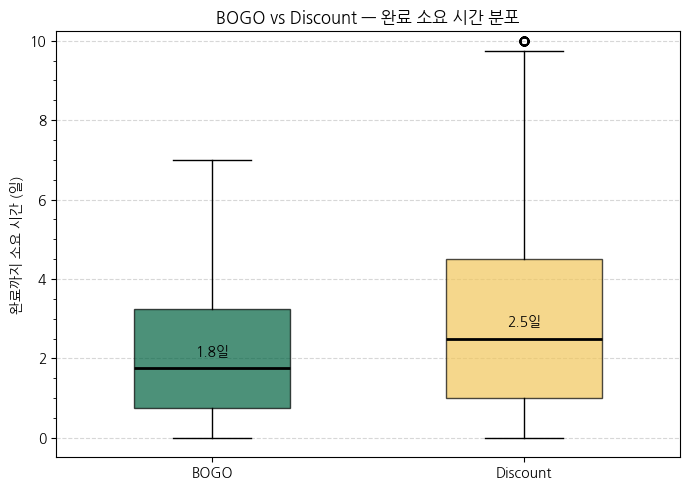

In [230]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plot_df = funnel[funnel['offer_type'].isin(['bogo', 'discount']) & funnel['is_completed']].copy()
plot_df['gap_days'] = plot_df['gap_to_complete'] / 24

fig, ax = plt.subplots(figsize=(7, 5))

groups = [
    plot_df.loc[plot_df['offer_type'] == 'bogo', 'gap_days'],
    plot_df.loc[plot_df['offer_type'] == 'discount', 'gap_days'],
]
bp = ax.boxplot(groups, labels=['BOGO', 'Discount'],
                patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))

colors = ['#006241', '#F2C75C']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 실제 whisker 끝값 기준으로 ylim 설정
whisker_bottoms = [w.get_ydata()[1] for w in bp['whiskers'][0::2]]
whisker_tops = [w.get_ydata()[1] for w in bp['whiskers'][1::2]]
margin = (max(whisker_tops) - min(whisker_bottoms)) * 0.05
ax.set_ylim(min(whisker_bottoms) - margin, max(whisker_tops) + margin)

ax.set_ylabel('완료까지 소요 시간 (일)')
ax.set_title('BOGO vs Discount — 완료 소요 시간 분포')
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 중앙값 텍스트 표시
for i, g in enumerate(groups, 1):
    ax.text(i, g.median() + margin * 0.5, f'{g.median():.1f}일',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [217]:
from scipy import stats

# bogo vs discount 열람 속도 (gap_to_view) — Mann-Whitney U
bogo_view = funnel.loc[(funnel['offer_type'] == 'bogo') & funnel['is_viewed'], 'gap_to_view']
disc_view  = funnel.loc[(funnel['offer_type'] == 'discount') & funnel['is_viewed'], 'gap_to_view']

for name, s in [('bogo', bogo_view), ('discount', disc_view)]:
    print(f"{name} 열람 건수: {len(s):,}  중앙값: {s.median()/24:.1f}일  평균: {s.mean()/24:.1f}일")

u_stat, p_val = stats.mannwhitneyu(bogo_view, disc_view, alternative='two-sided')
n1, n2 = len(bogo_view), len(disc_view)
r = 1 - (2 * u_stat) / (n1 * n2)

print(f"Mann-Whitney U test (열람 속도): U={u_stat:.0f}, p={p_val:.2e}")
if p_val < 0.05:
    diff = (disc_view.median() - bogo_view.median()) / 24
    faster = 'bogo' if diff > 0 else 'discount'
    print(f"→ p < 0.05: {faster}가 {abs(diff):.1f}일 빠르게 열람됨")
else:
    print("→ p >= 0.05: 유의미한 차이 없음")

print(f"효과 크기 (rank-biserial r) = {r:.3f}")
print(f"→ {'작음 (|r|<0.1)' if abs(r)<0.1 else '중간 (0.1≤|r|<0.3)' if abs(r)<0.3 else '큰 편 (|r|≥0.3)'}")

bogo 열람 건수: 25,250  중앙값: 0.5일  평균: 1.0일
discount 열람 건수: 21,370  중앙값: 0.5일  평균: 1.1일
Mann-Whitney U test (열람 속도): U=263321120, p=6.28e-06
→ p < 0.05: discount가 0.0일 빠르게 열람됨
효과 크기 (rank-biserial r) = 0.024
→ 작음 (|r|<0.1)


In [164]:
# 열람 후 완료까지 걸리는 시간 분포
funnel.groupby('offer_type')['gap_view_to_complete'].median()

offer_type
bogo             30.0
discount         42.0
informational     NaN
Name: gap_view_to_complete, dtype: float64

[ 열람 후 완료까지 소요 시간 ]
  bogo: n=9,413  중앙값=1.2일  평균=1.7일
  discount: n=11,135  중앙값=1.8일  평균=2.4일
Mann-Whitney U: U=42782219, p=8.75e-115
효과 크기 r=0.184 → 중간


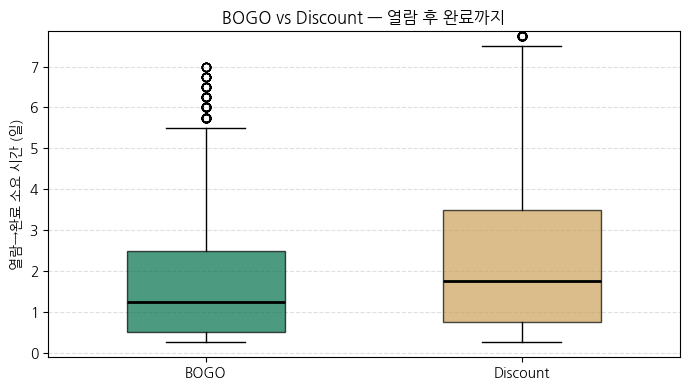

In [218]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

bd = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()

# ── 1. gap_view_to_complete 분포 (열람 후 완료까지) ──────────
print("[ 열람 후 완료까지 소요 시간 ]")
for otype, grp in bd.groupby('offer_type'):
    s = grp['gap_view_to_complete'].dropna()
    print(f"  {otype}: n={len(s):,}  중앙값={s.median()/24:.1f}일  평균={s.mean()/24:.1f}일")

bogo_vc = bd.loc[(bd['offer_type']=='bogo') & bd['gap_view_to_complete'].notna(), 'gap_view_to_complete']
disc_vc = bd.loc[(bd['offer_type']=='discount') & bd['gap_view_to_complete'].notna(), 'gap_view_to_complete']
u, p = stats.mannwhitneyu(bogo_vc, disc_vc, alternative='two-sided')
n1, n2 = len(bogo_vc), len(disc_vc)
r = 1 - (2 * u) / (n1 * n2)
print(f"Mann-Whitney U: U={u:.0f}, p={p:.2e}")
print(f"효과 크기 r={r:.3f} → {'작음' if abs(r)<0.1 else '중간' if abs(r)<0.3 else '큰 편'}")

# 박스플롯
fig, ax = plt.subplots(figsize=(7, 4))
groups = [bogo_vc / 24, disc_vc / 24]
bp = ax.boxplot(groups, labels=['BOGO', 'Discount'], patch_artist=True,
                widths=0.5, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#00704A', '#CBA258']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
whisker_bottoms = [w.get_ydata()[1] for w in bp['whiskers'][0::2]]
whisker_tops    = [w.get_ydata()[1] for w in bp['whiskers'][1::2]]
margin = (max(whisker_tops) - min(whisker_bottoms)) * 0.05
ax.set_ylim(min(whisker_bottoms) - margin, max(whisker_tops) + margin)
ax.set_ylabel('열람→완료 소요 시간 (일)')
ax.set_title('BOGO vs Discount — 열람 후 완료까지')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

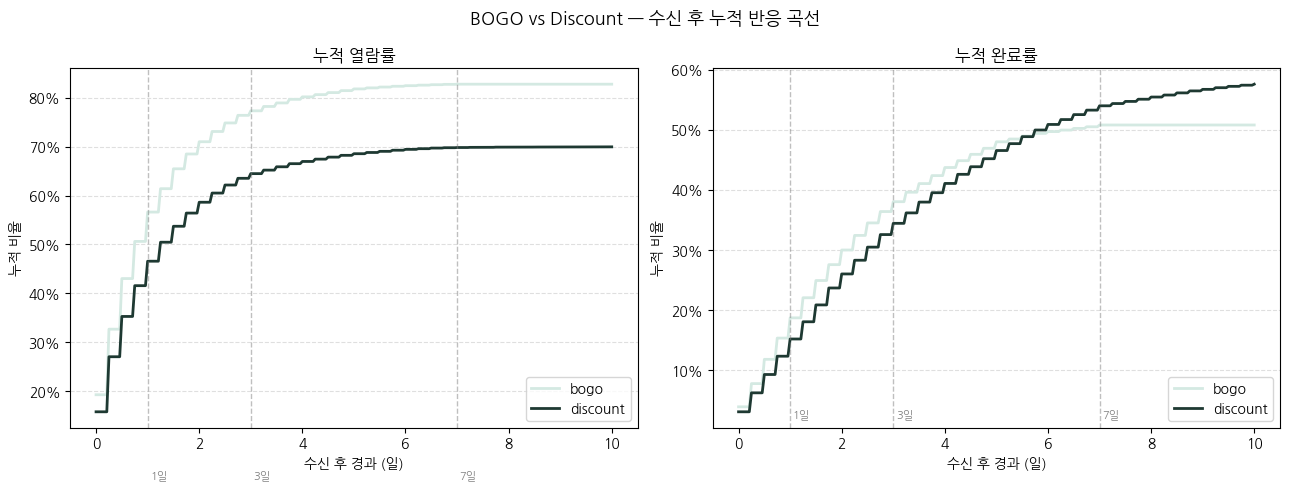

,열람_6h,완료_6h,열람_24h,완료_24h,열람_48h,완료_48h,열람_72h,완료_72h,열람_168h,완료_168h,유효기간내_완료
offer_type,,,,,,,,,,,
bogo,0.33,0.08,0.57,0.19,0.71,0.30,0.77,0.38,0.83,0.51,0.51
discount,0.27,0.06,0.47,0.15,0.59,0.26,0.64,0.34,0.70,0.54,0.58


In [166]:
import numpy as np
import matplotlib.pyplot as plt

bd = funnel[funnel['offer_type'].isin(['bogo', 'discount'])].copy()

# --- 1. 누적 반응 곡선 ---
time_points = np.arange(0, 24 * 10 + 1, 1)  # 0~10일, 1시간 단위
days = time_points / 24

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
colors = {'bogo': '#D4E9E2', 'discount': '#1E3932'}

for otype, grp in bd.groupby('offer_type'):
    n = len(grp)
    # 누적 열람률 (분모: 전체 수신)
    cum_view = [(grp['gap_to_view'].dropna() <= t).sum() / n for t in time_points]
    # 누적 완료률 (분모: 전체 수신)
    cum_comp = [(grp['gap_to_complete'].dropna() <= t).sum() / n for t in time_points]

    axes[0].plot(days, cum_view, label=otype, color=colors[otype], linewidth=2)
    axes[1].plot(days, cum_comp, label=otype, color=colors[otype], linewidth=2)

for ax, title in zip(axes, ['누적 열람률', '누적 완료률']):
    ax.set_xlabel('수신 후 경과 (일)')
    ax.set_ylabel('누적 비율')
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.axvline(1, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(3, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(7, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(1.05, 0.02, '1일', color='gray', fontsize=8)
    ax.text(3.05, 0.02, '3일', color='gray', fontsize=8)
    ax.text(7.05, 0.02, '7일', color='gray', fontsize=8)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('BOGO vs Discount — 수신 후 누적 반응 곡선', fontsize=13)
plt.tight_layout()
plt.show()

# --- 2. 주요 시점별 반응률 테이블 ---
thresholds = [6, 24, 48, 72, 168]   # 6h, 1d, 2d, 3d, 7d
rows = []
for otype, grp in bd.groupby('offer_type'):
    n = len(grp)
    row = {'offer_type': otype}
    for t in thresholds:
        row[f'열람_{t}h'] = (grp['gap_to_view'].dropna() <= t).sum() / n
        row[f'완료_{t}h'] = (grp['gap_to_complete'].dropna() <= t).sum() / n
    # 유효기간 내 완료
    within = (grp['is_completed'] & (grp['gap_to_complete'] <= grp['duration'] * 24)).sum() / n
    row['유효기간내_완료'] = within
    rows.append(row)

summary = pd.DataFrame(rows).set_index('offer_type')
rate_cols = [c for c in summary.columns]
#print(summary[rate_cols].to_string(float_format='{:.1%}'.format))
summary[rate_cols].round(2)

In [203]:
from scipy import stats

# --- duration 길이별 완료율 ---
print("[ duration(유효기간)별 완료율 ]")
dur_rate = (funnel[funnel['offer_type'].isin(['bogo', 'discount'])]
            .groupby(['offer_type', 'duration'])['is_completed']
            .agg(['mean', 'count'])
            .rename(columns={'mean': '완료율', 'count': '건수'}))
print(dur_rate.to_string(float_format='{:.1%}'.format))

# --- chi-square (offer_type별) ----
print("[chi-square (offer_type별)]")
for otype, grp in funnel[funnel['offer_type'].isin(['bogo','discount'])].groupby('offer_type'):
    ct = pd.crosstab(grp['duration'], grp['is_completed'])
    if ct.shape[0] < 2:
        print(f"  {otype}: duration 값이 1개라 검정 불가")
        continue
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  {otype}: chi2={chi2:.1f}, p={p:.2e} → {'유의' if p<0.05 else '비유의'}")

[ duration(유효기간)별 완료율 ]
                      완료율     건수
offer_type duration             
bogo       5.0      49.9%  15164
           7.0      51.8%  15335
discount   7.0      59.3%  15278
           10.0     56.0%  15265
[chi-square (offer_type별)]
  bogo: chi2=10.8, p=1.01e-03 → 유의
  discount: chi2=34.3, p=4.82e-09 → 유의


#### 수신 후 반응 집중 시점
---
- 열람: 24시간 내에 절반 이상 반응 (bogo 56.6%, discount 46.6%)
- 완료: 72시간까지 꾸준히 누적, 이후 증가폭 둔화
---
#### 초반 반응 속도
- bogo가 전 시점에서 열람/완료 모두 빠름 (6h 열람 32.7% vs 27.0%)
- 최종 완료율은 discount가 높음 (54.0% vs 50.8%) — bogo는 빨리 보지만 완료로 이어지지 않는 경향
---
#### 유효기간 내 완료 비율
- bogo 50.8%, discount 57.6%
- 대부분 7일(168h) 내에 완료 → 유효기간 연장보다 초반 24~72시간 내 전환을 유도하는 게 좋다?  

In [207]:
from scipy import stats

# --- 동일 오퍼 재수신 간격 vs 완료율 ---
# 같은 (customer_id, offer_id)를 여러 번 받은 경우만 추출
multi = (funnel.sort_values(['customer_id', 'offer_id', 't_received'])
               .copy())
multi['recv_gap'] = (multi.groupby(['customer_id', 'offer_id'])['t_received']
                          .diff())  # 직전 수신과의 간격 (시간)#groupby 후 .diff()는 같은 그룹 내 직전 행과의 차이

multi_only = multi[multi['recv_gap'].notna()].copy()  # 재수신 건만

print(f"재수신 인스턴스 수: {len(multi_only):,}건")
print(f"재수신 간격 중앙값: {multi_only['recv_gap'].median()/24:.1f}일")
print(f"재수신 간격 평균:   {multi_only['recv_gap'].mean()/24:.1f}일")

# 간격 구간별 완료율
bins  = [0, 24, 72, 168, float('inf')]
labels = ['1일 이내', '1~3일', '3~7일', '7일 초과']
multi_only['gap_bin'] = pd.cut(multi_only['recv_gap'], bins=bins, labels=labels)

print('')
print("[ 재수신 간격 구간별 완료율 ]")
print(multi_only.groupby('gap_bin', observed=True)['is_completed']
      .agg(['mean', 'count'])
      .rename(columns={'mean': '완료율', 'count': '건수'})
      .to_string(float_format='{:.1%}'.format))

# 스피어만 상관
r, p = stats.spearmanr(multi_only['recv_gap'], multi_only['is_completed'].astype(int))
print(f"재수신 간격 ↔ 완료율 스피어만 상관: r={r:.3f}, p={p:.2e}")
print('')
print(f"→ {'유의미한 관계 있음' if p < 0.05 else '유의미한 관계 없음'}")

재수신 인스턴스 수: 12,989건
재수신 간격 중앙값: 7.0일
재수신 간격 평균:   10.5일

[ 재수신 간격 구간별 완료율 ]
          완료율    건수
gap_bin            
1~3일    45.4%  1921
3~7일    44.4%  4604
7일 초과   43.8%  6464
재수신 간격 ↔ 완료율 스피어만 상관: r=-0.008, p=3.37e-01

→ 유의미한 관계 없음


In [229]:
# --- 몇 번째 수신에서 처음 열람하는가 (재발송 효과 검증) ---
fv = first_viewed_instance.copy()  # customer_id, offer_id, first_viewed_instance

# 분포
print("[ 처음 열람한 수신 차수 분포 ]")
dist = fv['first_viewed_instance'].value_counts().sort_index()#첫 열람 인스턴스 값 별 고객 수 
dist_pct = dist / dist.sum() * 100
for inst, cnt in dist.items():
    bar = '█' * int(dist_pct[inst] / 2)
    print(f"  {inst}번째 수신: {cnt:>6,}건 ({dist_pct[inst]:5.1f}%)  {bar}")

re_send_view_rate = (fv['first_viewed_instance'] >= 2).mean()

print(f"→ 재발송 후 첫 열람 비율: {re_send_view_rate:.1%}\n"
      f"  (나머지 {1-re_send_view_rate:.1%}는 첫 수신에서 바로 열람)")


# 열람을 유도한 재발송 간격 분석
trigger = (
    multi
    .merge(fv.rename(columns={'first_viewed_instance': 'fv_inst'}),
           on=['customer_id', 'offer_id'])
    .query('instance_id == fv_inst and fv_inst >= 2')
    .dropna(subset=['recv_gap'])
    .copy()
)
print('')
print(f"[ 열람을 처음 유도한 재발송 간격 (재발송 건 {len(trigger):,}개) ]")
print(f"  중앙값: {trigger['recv_gap'].median()/24:.1f}일")
print(f"  평균:   {trigger['recv_gap'].mean()/24:.1f}일")

bins   = [0, 24, 72, 168, float('inf')]
labels = ['1일 이내', '1~3일', '3~7일', '7일 초과']
trigger['gap_bin'] = pd.cut(trigger['recv_gap'], bins=bins, labels=labels)
gap_dist = trigger['gap_bin'].value_counts().sort_index()
gap_pct  = gap_dist / gap_dist.sum() * 100
print()
for g, cnt in gap_dist.items():
    print(f"  {g}: {cnt:>5,}건 ({gap_pct[g]:.1f}%)")

# 재발송 간격 구간별 '차수' — 짧은 간격일수록 더 빨리(낮은 차수에서) 열람?
print('')
print("[ 재발송 간격 구간별 첫 열람 차수 중앙값 ]")
print(trigger.groupby('gap_bin', observed=True)['fv_inst']
      .agg(['median', 'mean', 'count'])
      .rename(columns={'median': '차수 중앙값', 'mean': '차수 평균', 'count': '건수'})
      .to_string(float_format='{:.2f}'.format))


[ 처음 열람한 수신 차수 분포 ]
  1번째 수신: 47,024건 ( 97.5%)  ████████████████████████████████████████████████
  2번째 수신:  1,146건 (  2.4%)  █
  3번째 수신:     42건 (  0.1%)  
  4번째 수신:      1건 (  0.0%)  
→ 재발송 후 첫 열람 비율: 2.5%
  (나머지 97.5%는 첫 수신에서 바로 열람)

[ 열람을 처음 유도한 재발송 간격 (재발송 건 1,189개) ]
  중앙값: 7.0일
  평균:   9.6일

  1일 이내:     0건 (0.0%)
  1~3일:   245건 (20.6%)
  3~7일:   424건 (35.7%)
  7일 초과:   520건 (43.7%)

[ 재발송 간격 구간별 첫 열람 차수 중앙값 ]
         차수 중앙값  차수 평균   건수
gap_bin                    
1~3일       2.00   2.06  245
3~7일       2.00   2.05  424
7일 초과      2.00   2.01  520


In [169]:
funnel.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 't_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_view', 'gap_to_complete', 'is_viewed',
       'is_completed', 'completed_without_prior_view',
       'completed_within_prior_view', 'gap_view_to_complete', 'reward',
       'difficulty', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social',
       'channel_count', 'gender', 'age_group', 'income_group', 'join_year',
       'join_month', 'join_cohort'],
      dtype='str')

---
#### 📌 파트 3 인사이트 — 어떤 오퍼를 보내야 하는가

**오퍼 유형별 전환율**
- bogo는 열람률이 높지만(82.8%) 열람→완료 전환율이 낮음(43.3%) — 오퍼를 보긴 하나 조건 달성이 어려움
- discount는 열람률은 낮지만(70.0%) 한번 열람 시 완료율이 높음(57.7%) — 조건이 상대적으로 달성하기 쉬움

**난이도**
- 난이도가 높을수록 완료율 하락 (bogo/discount 모두 유의, p<0.05)
- bogo가 discount보다 난이도 민감도가 더 높음 — 로지스틱 회귀 상호작용항 유의 (p=0.0097)
- bogo 난이도 20짜리는 완료율 43.2%로 최저 — discount 난이도 10(45.5%)과 유사 수준

**채널**
- discount는 mobile/social 채널 포함 시 완료율 크게 상승 (+19~20%p)
- bogo는 채널 효과 제한적 — 난이도가 채널보다 완료율에 더 결정적

**기타**
- 완료의 약 30%는 오퍼를 인지하지 않고 달성 (bogo 29.4%, discount 30.0%) — 유형 간 차이 없음
---

---
#### 📌 파트 4 인사이트 — 어떤 간격으로 보내야 하는가

**완료/열람 속도**
- bogo가 discount보다 완료 속도 0.8일 빠름 (Mann-Whitney p=1.37e-241, r=0.211 중간 효과)
- 열람 속도도 bogo가 더 빠름 — 단, 최종 완료율은 discount가 높음 (54.0% vs 50.8%)
- 열람 후 완료까지도 bogo가 더 빠름 (중앙값 약 1.4일 vs discount 1.7일)

**반응 집중 시점**
- 수신 후 24시간 내 열람이 집중 (bogo 56.6%, discount 46.6%)
- 완료는 72시간까지 꾸준히 누적, 이후 증가폭 둔화
- 유효기간 내 완료율: bogo 50.8%, discount 57.6% — 대부분 7일 내 완료

**재발송 효과**
- 재수신 간격 ↔ 완료율: 스피어만 r=-0.008, p=0.337 → 유의미한 관계 없음
- 97.5%는 **첫 수신에서 바로 열람** — 재발송이 열람을 유도하는 경우는 2.5%에 불과
- 재발송 후 열람한 경우도 간격(1~3일 / 3~7일 / 7일 초과)과 무관하게 차수 중앙값 동일(2.0)

**발송 전략 시사점**
- 재발송 빈도·간격 조절보다 **첫 발송 품질(오퍼 내용, 채널 선택)** 이 핵심
- 유효기간 연장보다 수신 후 24~72시간 내 전환 유도가 효과적
- duration이 길다고 완료율이 높지 않음 (discount: 7일 59.3% > 10일 56.0%)
---

### 어떤 고객 집단에게 보내야 하는가 - 세그먼트 분석

In [187]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import proportion_confint
import warnings
warnings.filterwarnings('ignore')

# --- age_gender, income은 funnel에 없으므로 full에서 추가 ---
for col in ['age_gender', 'income']:
    if col not in funnel.columns:
        extra = full[['customer_id', col]].drop_duplicates('customer_id')
        funnel = funnel.merge(extra, on='customer_id', how='left')

# --- funnel_clean: 누락 제거 ---
funnel_clean = funnel[
    (funnel['income_group'] != '누락') &
    (funnel['age_group'] != '누락')&(funnel['income']!= 0)
].copy()
funnel_clean['aware_completed'] = (
    funnel_clean['is_completed'] & ~funnel_clean['completed_without_prior_view']
)

# --- transaction 데이터 (상위 1% 제거) ---
tx_raw = full[full['event'] == 'transaction'].copy()
amount_upper = tx_raw['amount'].quantile(0.99)
tx = tx_raw[tx_raw['amount'] <= amount_upper].copy()
merge_cols = ['customer_id'] + [c for c in ['gender', 'age_group', 'income_group', 'join_year'] if c not in tx.columns]
cust_attr = funnel[merge_cols].drop_duplicates('customer_id')
tx = tx.merge(cust_attr, on='customer_id', how='left')

print(f"amount 상위 1% 기준값: ${amount_upper:.2f}  제거: {len(tx_raw)-len(tx):,}건")
print(f"funnel_clean: {len(funnel_clean):,}건")

# --- 세그먼트별 5대 지표 계산 함수 ---
def segment_metrics(df, group_col, order=None):
    bd = df[df['offer_type'].isin(['bogo', 'discount'])].copy()
    res = bd.groupby(group_col).agg(
        n            =('instance_id', 'count'),
        open_rate    =('is_viewed', 'mean'),
        conv_rate    =('is_completed', 'mean'),
        aware_comp   =('aware_completed', 'sum'),
        viewed       =('is_viewed', 'sum'),
        unaware_comp =('completed_without_prior_view', 'sum'),
        completed    =('is_completed', 'sum'),
        gap_view_med =('gap_to_view', 'median'),
        gap_comp_med =('gap_to_complete', 'median'),
    )
    res['ctr']          = res['aware_comp'] / res['viewed']
    res['unaware_rate'] = res['unaware_comp'] / res['completed']
    res['gap_view_d']   = res['gap_view_med'] / 24
    res['gap_comp_d']   = res['gap_comp_med'] / 24
    out = res[['n', 'open_rate', 'conv_rate', 'ctr', 'unaware_rate', 'gap_view_d', 'gap_comp_d']]
    return out.reindex(order) if order else out

print("\nopen_rate: 수신→열람 | conv_rate: 수신→완료 | ctr: 열람→완료(인지)")
print("unaware_rate: 미인지완료 | gap_view_d: 열람까지(일) | gap_comp_d: 완료까지(일)")

amount 상위 1% 기준값: $40.02  제거: 1,390건
funnel_clean: 66,501건

open_rate: 수신→열람 | conv_rate: 수신→완료 | ctr: 열람→완료(인지)
unaware_rate: 미인지완료 | gap_view_d: 열람까지(일) | gap_comp_d: 완료까지(일)


In [210]:
print("[ 소득 구간별 분석 ]")
inc_order = ['5만 미만', '5-7.5만', '7.5-10만', '10만 이상']

# 5대 지표
inc_m = segment_metrics(funnel_clean, 'income_group', inc_order)
print("소득 구간별 5대 지표:")
print(inc_m.to_string(float_format='{:.1%}'.format))

# chi-square (완료율)
bd_inc = funnel_clean[funnel_clean['offer_type'].isin(['bogo', 'discount'])]
ct_inc = pd.crosstab(bd_inc['income_group'], bd_inc['is_completed'])
chi2_inc, p_inc, _, expected_inc = stats.chi2_contingency(ct_inc)
v_inc = np.sqrt(chi2_inc / (ct_inc.values.sum() * (min(ct_inc.shape)-1)))
print('')
print(f"기대빈도 최솟값: {expected_inc.min():.1f}  {'(>=5 OK)' if expected_inc.min()>=5 else '(<5 해석 주의)'}")
print(f"카이제곱: χ²={chi2_inc:.2f}, p={p_inc:.2e}, V={v_inc:.3f}  → {'유의' if p_inc<0.05 else '비유의'}")

# 거래금액: transaction-level + customer-level
inc_tx = tx[tx['income_group'].isin(inc_order)].copy()
print('')
print("소득 구간별 거래금액 (transaction 단위):")
inc_amt = inc_tx.groupby('income_group')['amount'].agg(['mean','median']).reindex(inc_order)
for i, row in inc_amt.iterrows():
    print(f"  {i:<10}  평균 ${row['mean']:.2f}  중앙값 ${row['median']:.2f}")

print('')
print("소득 구간별 1인당 평균 거래금액 (고객 단위):")
person_amt = inc_tx.groupby(['customer_id','income_group'])['amount'].mean().reset_index()
inc_person_amt = person_amt.groupby('income_group')['amount'].mean().reindex(inc_order)
for i, v in inc_person_amt.items():
    print(f"  {i:<10}  ${v:.2f}")

# ANOVA + Kruskal-Wallis + Tukey
groups_inc = [inc_tx[inc_tx['income_group']==i]['amount'].dropna().values for i in inc_order if len(inc_tx[inc_tx['income_group']==i])>0]
f_inc, p_anova_inc = stats.f_oneway(*groups_inc)
kw_inc, p_kw_inc   = stats.kruskal(*groups_inc)
print('')
print(f"ANOVA: F={f_inc:.2f}, p={p_anova_inc:.2e}")
print(f"Kruskal-Wallis: H={kw_inc:.2f}, p={p_kw_inc:.2e}  {'(ANOVA 결과와 일치)' if (p_anova_inc<0.05)==(p_kw_inc<0.05) else '(불일치, 비모수 기준 우선)'}")

tukey_df_data = inc_tx[['income_group','amount']].dropna()
tukey_inc = pairwise_tukeyhsd(tukey_df_data['amount'], tukey_df_data['income_group'], alpha=0.05)
tukey_df = pd.DataFrame(data=tukey_inc._results_table.data[1:], columns=tukey_inc._results_table.data[0])
sig = tukey_df[tukey_df['reject']==True][['group1','group2','meandiff','p-adj']]
print('')
print("Tukey HSD (유의한 쌍만):")
if len(sig)>0:
    for _, row in sig.iterrows():
        print(f"  {row['group1']} vs {row['group2']}: 차이 ${float(row['meandiff']):.2f}  p={float(row['p-adj']):.4f}")
else:
    print("  유의한 쌍 없음")

[ 소득 구간별 분석 ]
소득 구간별 5대 지표:
                  n  open_rate  conv_rate   ctr  unaware_rate  gap_view_d  gap_comp_d
income_group                                                                         
5만 미만         13618      69.0%      43.8% 43.2%         32.1%       75.0%      250.0%
5-7.5만        23152      78.1%      59.4% 55.2%         27.5%       50.0%      200.0%
7.5-10만       12479      80.7%      74.3% 64.4%         30.1%       50.0%      175.0%
10만 이상         3952      68.8%      76.5% 67.2%         39.6%       75.0%      200.0%

기대빈도 최솟값: 1574.9  (>=5 OK)
카이제곱: χ²=3006.33, p=0.00e+00, V=0.238  → 유의

소득 구간별 거래금액 (transaction 단위):
  5만 미만       평균 $5.79  중앙값 $4.42
  5-7.5만      평균 $10.90  중앙값 $10.38
  7.5-10만     평균 $22.21  중앙값 $21.96
  10만 이상      평균 $26.09  중앙값 $26.06

소득 구간별 1인당 평균 거래금액 (고객 단위):
  5만 미만       $5.35
  5-7.5만      $11.16
  7.5-10만     $22.32
  10만 이상      $26.02

ANOVA: F=36591.57, p=0.00e+00
Kruskal-Wallis: H=52578.23, p=0.00e+00  (ANOVA 결과와 일치)

Tukey HSD (유

In [212]:
print("[ 성별 분석 ]")
gender_order = ['M', 'F', 'O']

gen_m = segment_metrics(funnel_clean, 'gender', gender_order)
print("성별 5대 지표:")
print(gen_m.to_string(float_format='{:.1%}'.format))

bd_g = funnel_clean[funnel_clean['offer_type'].isin(['bogo','discount']) & funnel_clean['gender'].isin(gender_order)]

# 완료율 히트맵
heatmap_gender = bd_g.groupby(['gender','offer_type'])['is_completed'].mean().unstack() * 100
print('')
print("완료율 히트맵 (%):")
print(heatmap_gender.reindex(gender_order).round(1))

# chi-square
ct_g = pd.crosstab(bd_g['gender'], bd_g['is_completed'])
chi2_g, p_g, _, expected_g = stats.chi2_contingency(ct_g)
v_g = np.sqrt(chi2_g / (ct_g.values.sum() * (min(ct_g.shape)-1)))
print('')
print(f"기대빈도 최솟값: {expected_g.min():.1f}  {'(>=5 OK)' if expected_g.min()>=5 else '(<5 해석 주의)'}")
print(f"χ²={chi2_g:.2f}, p={p_g:.2e}, V={v_g:.3f}  → {'유의' if p_g<0.05 else '비유의'}")

# 오퍼 유형별 성별 완료율 + 95% CI
print('')
print("오퍼 유형별 성별 완료율 + 95% CI:")
for ot in ['bogo', 'discount']:
    sub = bd_g[bd_g['offer_type']==ot]
    for g in ['F', 'M']:
        g_sub = sub[sub['gender']==g]
        n, k = len(g_sub), g_sub['is_completed'].sum()
        lo, hi = proportion_confint(k, n, alpha=0.05, method='wilson')
        print(f"  {ot:<12} {g}  {k/n*100:.1f}%  95%CI [{lo*100:.1f}%, {hi*100:.1f}%]  (n={n:,})")

[ 성별 분석 ]
성별 5대 지표:
            n  open_rate  conv_rate   ctr  unaware_rate  gap_view_d  gap_comp_d
gender                                                                         
M       30562      74.9%      53.0% 50.4%         28.9%       50.0%      200.0%
F       21918      76.5%      69.8% 62.2%         31.8%       50.0%      175.0%
O         721      84.9%      68.4% 63.1%         21.7%       50.0%      175.0%

완료율 히트맵 (%):
offer_type  bogo  discount
gender                    
M           48.8      57.2
F           67.7      71.9
O           68.1      68.7

기대빈도 최솟값: 287.3  (>=5 OK)
χ²=1515.05, p=0.00e+00, V=0.169  → 유의

오퍼 유형별 성별 완료율 + 95% CI:
  bogo         F  67.7%  95%CI [66.9%, 68.6%]  (n=10,975)
  bogo         M  48.8%  95%CI [48.0%, 49.6%]  (n=15,208)
  discount     F  71.9%  95%CI [71.0%, 72.7%]  (n=10,943)
  discount     M  57.2%  95%CI [56.4%, 58.0%]  (n=15,354)


In [213]:
print("[연령대 분석 ]")
age_order = ['20대 미만', '20대', '30대', '40대', '50대', '60대 이상']

age_m = segment_metrics(funnel_clean, 'age_group', age_order)
print("연령대별 5대 지표:")
print(age_m.to_string(float_format='{:.1%}'.format))

bd_a = funnel_clean[funnel_clean['offer_type'].isin(['bogo','discount']) & funnel_clean['age_group'].isin(age_order)].copy()

# 완료율 히트맵 + n
heatmap_age = bd_a.groupby(['age_group','offer_type'])['is_completed'].mean().unstack() * 100
n_age = bd_a.groupby(['age_group','offer_type'])['is_completed'].count().unstack()
print('')
print("완료율 히트맵 (%, 괄호 n):")
for age in age_order:
    row = []
    for ot in ['bogo','discount']:
        rate = heatmap_age.loc[age, ot] if ot in heatmap_age.columns else float('nan')
        n = int(n_age.loc[age, ot]) if ot in n_age.columns else 0
        row.append(f"{ot}: {rate:.1f}% (n={n})")
    print(f"  {age:<8}  " + "  ".join(row))

# chi-square
ct_a = pd.crosstab(bd_a['age_group'], bd_a['is_completed'])
chi2_a, p_a, _, expected_a = stats.chi2_contingency(ct_a)
v_a = np.sqrt(chi2_a / (ct_a.values.sum() * (min(ct_a.shape)-1)))
print(f"기대빈도 최솟값: {expected_a.min():.1f}  {'(>=5 OK)' if expected_a.min()>=5 else '(<5 해석 주의)'}")
print(f"χ²={chi2_a:.2f}, p={p_a:.2e}, V={v_a:.3f}  → {'유의' if p_a<0.05 else '비유의'}")
print(f"효과 크기: {'강함' if v_a>=0.3 else '중간' if v_a>=0.1 else '약함'}")
print('')
print("discount - bogo 완료율 차이 (연령대별):")
diff = heatmap_age.get('discount', 0) - heatmap_age.get('bogo', 0)
for age, d in diff.items():
    print(f"  {age:<8}  {d:+.1f}%p")

[연령대 분석 ]
연령대별 5대 지표:
               n  open_rate  conv_rate   ctr  unaware_rate  gap_view_d  gap_comp_d
age_group                                                                         
20대 미만       722      70.6%      43.6% 40.0%         35.2%       75.0%      225.0%
20대         4997      70.0%      47.0% 44.5%         33.7%       75.0%      225.0%
30대         5515      72.8%      53.7% 52.2%         29.3%       50.0%      200.0%
40대         8241      79.3%      58.1% 55.1%         24.8%       50.0%      200.0%
50대        12692      76.0%      64.3% 58.3%         31.0%       75.0%      200.0%
60대 이상     21034      76.3%      63.8% 57.6%         31.1%       50.0%      200.0%

완료율 히트맵 (%, 괄호 n):
  20대 미만    bogo: 36.7% (n=381)  discount: 51.3% (n=341)
  20대       bogo: 42.7% (n=2450)  discount: 51.1% (n=2547)
  30대       bogo: 49.4% (n=2710)  discount: 57.8% (n=2805)
  40대       bogo: 54.9% (n=4184)  discount: 61.4% (n=4057)
  50대       bogo: 62.2% (n=6322)  discount: 66.4% (n=6370)
 

In [191]:
print("[연령×성별 완료율 ]")

age_gender_order = [
    '20세 미만 남성', '20세 미만 여성',
    '20대 남성', '20대 여성', '30대 남성', '30대 여성',
    '40대 남성', '40대 여성', '50대 남성', '50대 여성',
    '60대 남성', '60대 여성', '60+ 남성', '60+ 여성',
]

bd_ag = funnel_clean[
    funnel_clean['offer_type'].isin(['bogo','discount']) &
    funnel_clean['age_gender'].isin(age_gender_order)
].copy()

heatmap_ag = bd_ag.groupby(['age_gender','offer_type'])['is_completed'].mean().unstack() * 100
n_ag = bd_ag.groupby(['age_gender','offer_type'])['is_completed'].count().unstack()

print("완료율 (%) — n<100인 셀은 '표본 부족'으로 표시:")
for ag in age_gender_order:
    if ag not in heatmap_ag.index:
        continue
    row = []
    for ot in ['bogo','discount']:
        n = int(n_ag.loc[ag, ot]) if ot in n_ag.columns else 0
        rate = heatmap_ag.loc[ag, ot] if ot in heatmap_ag.columns else float('nan')
        if n < 100:
            row.append(f"{ot}: 표본 부족(n={n})")
        elif pd.notna(rate):
            row.append(f"{ot}: {rate:.1f}%(n={n})")
        else:
            row.append(f"{ot}: -")
    print(f"  {ag:<14}  " + "  ".join(row))

# chi-square는 n>=100인 그룹만 포함
valid_ag = [
    ag for ag in age_gender_order
    if ag in n_ag.index and all(n_ag.loc[ag, ot] >= 100 for ot in n_ag.columns if ot in ['bogo','discount'])
]
bd_ag_valid = bd_ag[bd_ag['age_gender'].isin(valid_ag)]
ct_ag = pd.crosstab(bd_ag_valid['age_gender'], bd_ag_valid['is_completed'])
chi2_ag, p_ag, _, expected_ag = stats.chi2_contingency(ct_ag)
v_ag = np.sqrt(chi2_ag / (ct_ag.values.sum() * (min(ct_ag.shape)-1)))
print(f"✔︎ chi-square: n≥100 그룹({len(valid_ag)}개)만 포함")
print(f"기대빈도 최솟값: {expected_ag.min():.1f}  {'(>=5 OK)' if expected_ag.min()>=5 else '(<5 해석 주의)'}")
print(f"χ²={chi2_ag:.2f}, p={p_ag:.2e}, V={v_ag:.3f}  → {'유의' if p_ag<0.05 else '비유의'}")

[연령×성별 완료율 ]
완료율 (%) — n<100인 셀은 '표본 부족'으로 표시:
  20세 미만 남성       bogo: 31.6%(n=294)  discount: 51.5%(n=270)
  20세 미만 여성       bogo: 표본 부족(n=87)  discount: 표본 부족(n=71)
  20대 남성          bogo: 34.5%(n=1687)  discount: 45.5%(n=1816)
  20대 여성          bogo: 61.4%(n=736)  discount: 66.2%(n=701)
  30대 남성          bogo: 41.3%(n=1795)  discount: 52.1%(n=1874)
  30대 여성          bogo: 65.4%(n=876)  discount: 69.2%(n=891)
  40대 남성          bogo: 48.6%(n=2626)  discount: 56.5%(n=2505)
  40대 여성          bogo: 65.0%(n=1495)  discount: 69.1%(n=1484)
  50대 남성          bogo: 55.1%(n=3455)  discount: 60.2%(n=3445)
  50대 여성          bogo: 70.8%(n=2781)  discount: 73.6%(n=2827)
  60대 남성          bogo: 51.3%(n=2931)  discount: 61.5%(n=2923)
  60대 여성          bogo: 69.1%(n=2346)  discount: 74.1%(n=2441)
  60+ 남성          bogo: 54.8%(n=2420)  discount: 61.8%(n=2521)
  60+ 여성          bogo: 67.9%(n=2654)  discount: 72.4%(n=2528)
✔︎ chi-square: n≥100 그룹(13개)만 포함
기대빈도 최솟값: 225.3  (>=5 OK)
χ²=2046.17, p=0.00e+00

In [214]:
print("[ 가입년도별 분석 ]")

if 'join_year' not in funnel_clean.columns:
    join_attr = full[['customer_id','join_year']].drop_duplicates('customer_id')
    funnel_clean = funnel_clean.merge(join_attr, on='customer_id', how='left')
if 'join_year' not in tx.columns:
    join_attr = full[['customer_id','join_year']].drop_duplicates('customer_id')
    tx = tx.merge(join_attr, on='customer_id', how='left')

cohort_order = sorted(funnel_clean['join_year'].dropna().unique())

cohort_m = segment_metrics(funnel_clean, 'join_year', cohort_order)
print("가입년도별 5대 지표:")
print(cohort_m.to_string(float_format='{:.1%}'.format))

fd = funnel_clean[funnel_clean['offer_type'].isin(['bogo','discount'])].copy()
ct_c = pd.crosstab(fd['join_year'], fd['is_completed'])
chi2_c, p_c, _, expected_c = stats.chi2_contingency(ct_c)
v_c = np.sqrt(chi2_c / (ct_c.values.sum() * (min(ct_c.shape)-1)))
print(f"기대빈도 최솟값: {expected_c.min():.1f}  {'(>=5 OK)' if expected_c.min()>=5 else '(<5 해석 주의)'}")
print(f"χ²={chi2_c:.2f}, p={p_c:.2e}, V={v_c:.3f}  → {'유의' if p_c<0.05 else '비유의'}")

cohort_tx = tx[tx['join_year'].isin(cohort_order)].copy()
cohort_amt = cohort_tx.groupby('join_year')['amount'].agg(['mean','median']).reindex(cohort_order)
print('')
print("가입년도별 평균 거래금액:")
for y, row in cohort_amt.iterrows():
    print(f"  {int(y)}년  평균 ${row['mean']:.2f}  중앙값 ${row['median']:.2f}")

[ 가입년도별 분석 ]
가입년도별 5대 지표:
               n  open_rate  conv_rate   ctr  unaware_rate  gap_view_d  gap_comp_d
join_year                                                                         
2013         982      75.6%      56.3% 56.2%         24.6%       75.0%      275.0%
2014        2371      76.3%      54.8% 54.8%         23.8%       75.0%      300.0%
2015        5748      75.4%      74.0% 68.4%         30.3%       75.0%      175.0%
2016       10807      77.0%      81.6% 74.1%         30.1%       50.0%      175.0%
2017       20034      75.5%      59.7% 54.7%         30.9%       50.0%      200.0%
2018       13259      74.8%      38.5% 35.6%         30.9%       50.0%      250.0%
기대빈도 최솟값: 391.3  (>=5 OK)
χ²=5160.48, p=0.00e+00, V=0.311  → 유의

가입년도별 평균 거래금액:
  2013년  평균 $5.75  중앙값 $3.17
  2014년  평균 $5.80  중앙값 $3.14
  2015년  평균 $11.10  중앙값 $8.77
  2016년  평균 $13.07  중앙값 $12.25
  2017년  평균 $11.67  중앙값 $9.89
  2018년  평균 $9.26  중앙값 $5.97


---
#### 📌 파트 1 인사이트 — 어떤 고객 집단에게 보내야 하는가

**소득**
- 소득↑ → 완료율↑ 뚜렷 (43.8% → 76.5%), open_rate는 중간 소득이 더 높음
- 거래금액도 소득과 비례 ($5.35 → $26.02), transaction/customer-level 모두 일치 → heavy buyer 왜곡 없음
- 10만 이상은 open_rate가 낮은데(68.8%) 완료율은 최고 → 열람 안 해도 알아서 완료하는 경향 (unaware_rate 39.6% 최고)

**성별**
- 여성이 남성보다 완료율 일관되게 높음 (F 69.8% vs M 53.0%), 오퍼 유형 관계없이
- bogo 남녀 차이(19%p)가 discount(14.7%p)보다 큼 → 남성은 특히 bogo 달성이 어려움

**연령대**
- 나이↑ → 완료율↑ 경향 (43.6% → 63.8%)
- 젊은 층일수록 discount가 bogo보다 훨씬 유리 (20대 미만 차이 +14.6%p, 50대 +4.2%p)

**연령×성별**
- 모든 연령대에서 여성 > 남성
- 20대 남성 bogo 34.5%로 최저 → 핵심 취약 세그먼트

**가입년도**
- 2016년 가입자가 완료율 최고(81.6%), 2018년 최저(38.5%) — 코호트 간 격차 큼 (V=0.311 강한 효과)
- 2013~2014년은 거래금액이 낮음 ($5.75) — 초기 가입자가 소액 구매자
---

누구에게 → 고소득 + 중간 소득 여성 + 40~60대<br>
어떤 오퍼를 →<br>
 - 고소득: discount (unaware_rate 높아 오퍼 없이도 완료 → 인지 효과 극대화) 
 - 중간 소득 여성·40~60대: bogo(빠른 반응) or discount(높은 완료율)<br>

어떤 간격으로 → 수신 후 24시간 내 열람 유도, 72시간 내 완료 집중<br>